In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [2]:
# carregando o CIFAR 10 classes, imagens 32x32 RGB
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
print(x_train.shape, x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
(50000, 32, 32, 3) (10000, 32, 32, 3)


In [3]:
K = len(set(y_train))  # 10 classes
print('classes:', K)

classes: 10


In [5]:
i = Input(shape=x_train[0].shape)

# bloco 1 filtros pequenos pra pegar bordas
x = Conv2D(64,  (3, 3), strides=2, activation='relu', padding='same')(i)

# bloco 2 dobra os filtros
x = Conv2D(128, (3, 3), strides=2, activation='relu', padding='same')(x)

# bloco 3 mais profundidade
x = Conv2D(256, (3, 3), strides=2, activation='relu', padding='same')(x)

# GlobalAveragePooling em vez de Flatten menos parâmetros e mais robusto
x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 439,178 (1.68 MB)

 Trainable params: 439,178 (1.68 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 114s 72ms/step - accuracy: 0.2456 - loss: 1.9710 - val_accuracy: 0.4302 - val_loss: 1.5406
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 116s 74ms/step - accuracy: 0.4342 - loss: 1.5256 - val_accuracy: 0.5148 - val_loss: 1.3235
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 71ms/step - accuracy: 0.4981 - loss: 1.3650 - val_accuracy: 0.5473 - val_loss: 1.2341
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 117s 75ms/step - accuracy: 0.5355 - loss: 1.2672 - val_accuracy: 0.5777 - val_loss: 1.1597
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 75ms/step - accuracy: 0.5621 - loss: 1.1945 - val_accuracy: 0.5896 - val_loss: 1.1192
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 111s 71ms/step - accuracy: 0.5873 - loss: 1.1278 - val_accuracy: 0.6049 - val_loss: 1.0878
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 115s 74ms/step - accuracy: 0.6049 - loss: 1.0811 - val_accuracy: 0.6222 - val_loss: 1.0479
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 111s 71ms/step - accuracy: 

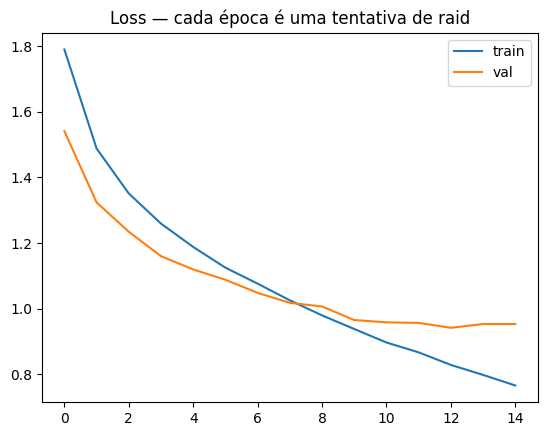

In [7]:
# loss por época
plt.plot(r.history['loss'], label='train')
plt.plot(r.history['val_loss'], label='val')
plt.title('Loss — cada época é uma tentativa de raid')
plt.legend()
plt.show()

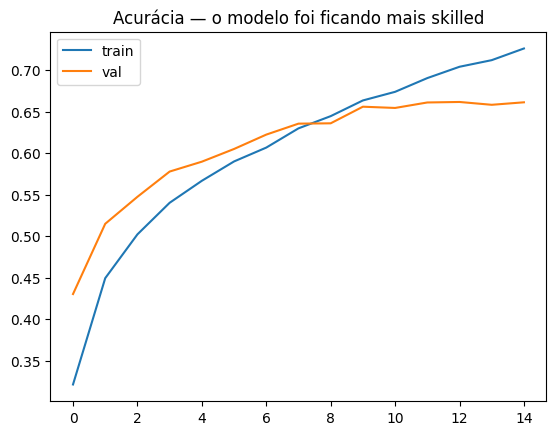

In [8]:
# acurácia
plt.plot(r.history['accuracy'], label='train')
plt.plot(r.history['val_accuracy'], label='val')
plt.title('Acurácia — o modelo foi ficando mais skilled')
plt.legend()
plt.show()

In [11]:
from sklearn.metrics import confusion_matrix # importa a função que calcula a matriz
import itertools# biblioteca auxiliar para facilitar a criação de loops

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


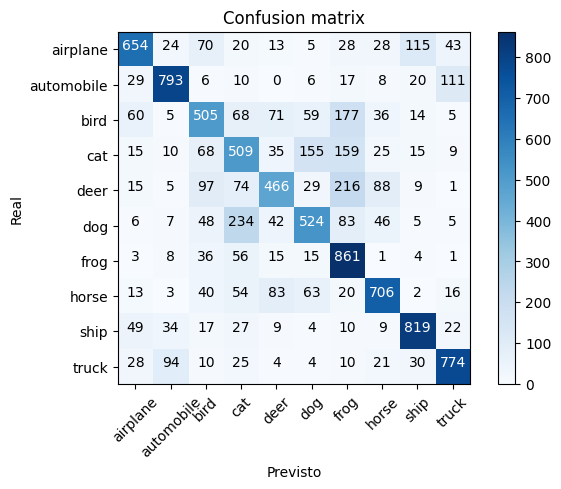

In [12]:
# define a função que vai desenhar o gráfico
def plot_confusion_matrix(cm, classes, normalize=False,
                          title='Confusion matrix', cmap=plt.cm.Blues):

    # se normalize for True transforma os números brutos em porcentagens
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # desenha a matriz como uma imagem colorida
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title) # título do gráfico
    plt.colorbar()   # adiciona a barra lateral que indica a escala de cores

    # configura os nomes das categorias nos eixos X e Y
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45) # nomes embaixo, inclinados em 45 graus
    plt.yticks(tick_marks, classes)               # nomes na lateral

    # define se o texto dentro dos quadrados será decimal ou número inteiro
    fmt = '.2f' if normalize else 'd'

    # define um limite de cor para o texto
    thresh = cm.max() / 2.

    # loop que percorre a matriz para escrever o valor numérico nele
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout() # ajusta o layout para não cortar as legendas
    plt.ylabel('Real') # legenda do eixo vertical
    plt.xlabel('Previsto') # legenda do eixo horizontal
    plt.show() # exibe o gráfico final na tela

# lista com os nomes das 10 categorias
labels = ['airplane','automobile','bird','cat','deer',
          'dog','frog','horse','ship','truck']

p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, labels)